In [2]:
import numpy as np
import pandas as pd
import joblib

X_train_final, X_test_final, y_train, y_test = joblib.load('../data/processed/train_test_split.pkl')
print(X_train_final.shape, X_test_final.shape)

(4184904, 14) (1046226, 14)


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import time

start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf_model.fit(X_train_final, y_train)

print(f"\nTraining time: {time.time() - start:.2f} seconds")

y_pred_rf = rf_model.predict(X_test_final)
y_proba_rf = rf_model.predict_proba(X_test_final)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("AUC-ROC:", roc_auc_score(y_test, y_proba_rf))

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  3.4min finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.



Training time: 202.83 seconds


[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.4s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    1.8s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.4s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    1.8s finished


Accuracy: 0.6181723642884043
Precision: 0.2741177243751232
Recall: 0.6475068822056176
F1 Score: 0.3851744230786989
AUC-ROC: 0.6799136678270419


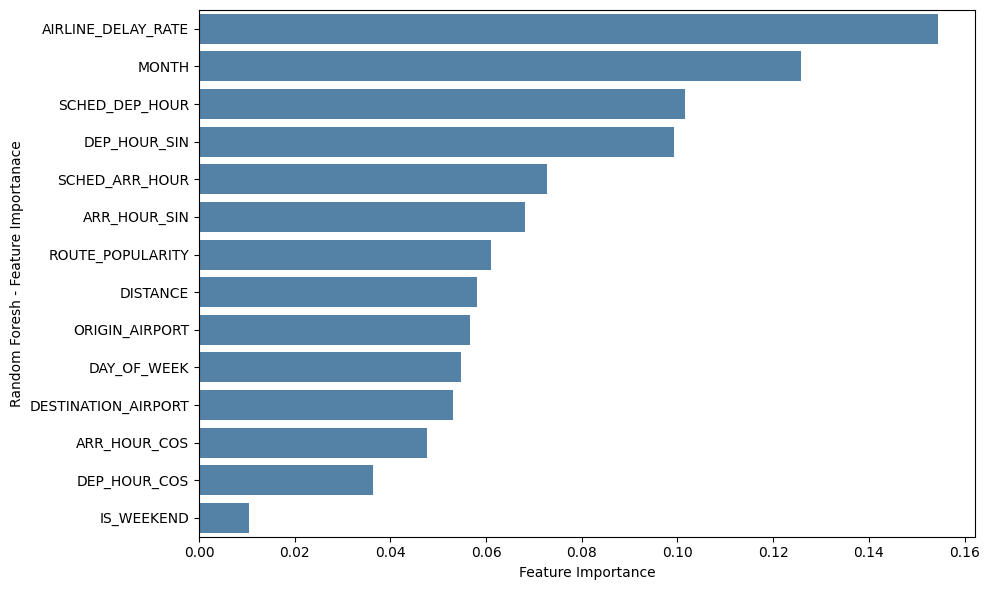

AIRLINE_DELAY_RATE     0.154402
MONTH                  0.125877
SCHED_DEP_HOUR         0.101475
DEP_HOUR_SIN           0.099329
SCHED_ARR_HOUR         0.072672
ARR_HOUR_SIN           0.068071
ROUTE_POPULARITY       0.060996
DISTANCE               0.058099
ORIGIN_AIRPORT         0.056699
DAY_OF_WEEK            0.054826
DESTINATION_AIRPORT    0.053045
ARR_HOUR_COS           0.047710
DEP_HOUR_COS           0.036385
IS_WEEKEND             0.010413
dtype: float64


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = pd.Series(rf_model.feature_importances_, index=X_train_final.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, color='steelblue')
plt.xlabel("Feature Importance")
plt.ylabel("Random Foresh - Feature Importanace")
plt.tight_layout()
plt.savefig('../reports/figures/rf_feature_importance.png', dpi=150)
plt.show()

print(importances)

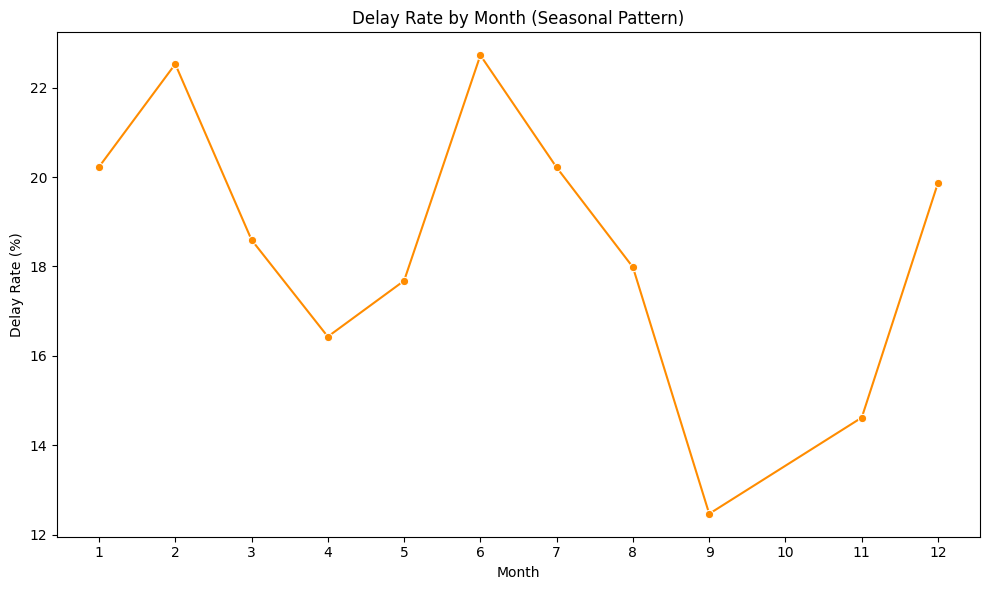

In [ ]:
month_delay = X_train_final.join(y_train).groupby('MONTH')['IS_DELAY'].mean() * 100

plt.figure(figsize=(10, 6))
sns.lineplot(x=month_delay.index, y=month_delay.values, marker='o', color='darkorange')
plt.xlabel('Month')
plt.ylabel('Delay Rate (%)')
plt.title('Delay Rate by Month (Seasonal Pattern)')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.savefig('../reports/figures/month_delay_rate.png', dpi=150)
plt.show()

In [6]:
joblib.dump(rf_model, '../src/random_forest_model.pkl')
print("Saved!")

Saved!
